# Image Captioning From Scratch — Version Optimisée

## Projet 2A — École d'Ingénieur

**Objectif** : Générer automatiquement une description en langage naturel à partir d'une image.

**Contrainte** : Tout le modèle est construit **from scratch** (pas de poids pré-entraînés).

**Architecture** :
```
Image → CNN Encoder (from scratch) → vecteur de features → LSTM Decoder → "A dog is running in the park"
```

**Dataset** : MS COCO 2017 (~118k images train, **2 captions par image** pour limiter la charge)

### Plateforme : Kaggle (GPU)

### Améliorations clés de cette version :
- **Images 224×224** (au lieu de 128) pour des features plus riches
- **Pack padded sequences** dans le LSTM pour ignorer correctement le padding
- **Scheduled teacher forcing** : ratio décroissant pour réduire l'exposure bias
- **Label smoothing** dans la loss pour améliorer la généralisation
- **Data augmentation complète** (RandomRotation + ColorJitter)
- **2 couches LSTM** pour plus de capacité sur COCO
- **Évaluation BLEU multi-références** (2 captions par image)
- **Système de reprise d'entraînement** (checkpoint resume)

---


## Étape 0 — Imports et Configuration

In [2]:
!pip install torch==2.4.1 torchvision==0.19.1 --break-system-packages -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 4.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 90.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 70.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 33.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━

In [3]:
import os
import json
import random
import math
import time
import shutil
from collections import Counter, defaultdict
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
%matplotlib inline
# Kaggle : pas besoin de monter Google Drive
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.4.1+cu121
CUDA disponible : True
GPU : Tesla P100-PCIE-16GB
VRAM : 17.1 GB


### Chargement du dataset MS COCO 2017

Sur Kaggle, on utilise le dataset COCO 2017 directement depuis les datasets Kaggle.

**Prérequis** : Ajoutez le dataset **`awsaf49/coco-2017-dataset`** à votre notebook Kaggle (bouton "Add Data" → chercher "coco 2017").

Les données seront disponibles dans `/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/`.

In [4]:
# ====== VÉRIFICATION DU DATASET COCO 2017 (Kaggle) ======
import os

# Sur Kaggle, le dataset est monté en lecture seule dans /kaggle/input/
# Ajoutez le dataset "awsaf49/coco-2017-dataset" à votre notebook
KAGGLE_COCO_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/"

if os.path.exists(KAGGLE_COCO_DIR):
    print(" Dataset COCO 2017 trouvé sur Kaggle")
    print(f"Contenu de {KAGGLE_COCO_DIR} :")
    for f in os.listdir(KAGGLE_COCO_DIR):
        full = os.path.join(KAGGLE_COCO_DIR, f)
        if os.path.isdir(full):
            n = len(os.listdir(full))
            print(f"   {f}/ ({n} fichiers)")
        else:
            print(f"   {f}")
else:
    print(" Dataset COCO non trouvé !")
    print("Ajoutez le dataset awsaf49/coco-2017-dataset via le bouton Add Data")


 Dataset COCO 2017 trouvé sur Kaggle
Contenu de /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/ :
   val2017/ (5000 fichiers)
   annotations/ (6 fichiers)
   test2017/ (40670 fichiers)
   train2017/ (118287 fichiers)


In [5]:
import os
import json as json_lib

COCO_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/"

# Vérifier la structure
print("Contenu du dossier COCO :")
for f in os.listdir(COCO_DIR):
    full = os.path.join(COCO_DIR, f)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f"   {f}/ ({n} fichiers)")
    else:
        print(f"   {f}")

# Vérifier les annotations
ann_train = os.path.join(COCO_DIR, "annotations", "captions_train2017.json")
ann_val = os.path.join(COCO_DIR, "annotations", "captions_val2017.json")

with open(ann_train, 'r') as f:
    data = json_lib.load(f)
print(f"\nAnnotations train : {len(data['annotations'])} captions, {len(data['images'])} images")

with open(ann_val, 'r') as f:
    data = json_lib.load(f)
print(f"Annotations val   : {len(data['annotations'])} captions, {len(data['images'])} images")


Contenu du dossier COCO :
   val2017/ (5000 fichiers)
   annotations/ (6 fichiers)
   test2017/ (40670 fichiers)
   train2017/ (118287 fichiers)

Annotations train : 591753 captions, 118287 images
Annotations val   : 25014 captions, 5000 images


### Hyperparamètres

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `IMG_SIZE` | 224 | Plus de détails visuels pour le CNN (vs 128 dans Fixed) |
| `BATCH_SIZE` | 32 | Compromis mémoire GPU / stabilité des gradients avec images 224×224 |
| `LEARNING_RATE` | 3e-4 | "The Karpathy constant" — excellent default pour Adam |
| `NUM_LSTM_LAYERS` | 2 | Plus de capacité pour COCO (vocabulaire plus riche) |
| `CAPTIONS_PER_IMAGE` | 2 | Limite à 2 captions/image pour réduire la charge mémoire |
| `LABEL_SMOOTHING` | 0.1 | Régularise les logits, empêche le modèle d'être trop confiant |
| `TF_START / TF_END` | 1.0 → 0.6 | Teacher forcing décroissant pour réduire l'exposure bias |


In [28]:
class Config:
    # --- Chemins COCO ---
    COCO_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/"
    TRAIN_IMAGES_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/"
    VAL_IMAGES_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/"
    TRAIN_ANNOT = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json"
    VAL_ANNOT = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json"

    # --- Vocabulaire ---
    MIN_WORD_FREQ = 5
    MAX_CAPTION_LEN = 40

    # --- Captions par image ---
    CAPTIONS_PER_IMAGE = 2    # ← On ne garde que 2 captions par image (au lieu de 5)

    # --- Image ---
    IMG_SIZE = 224
    IMG_CHANNELS = 3

    # --- Encoder CNN ---
    CNN_EMBED_DIM = 512

    # --- Decoder LSTM ---
    EMBED_DIM = 256
    HIDDEN_DIM = 512
    NUM_LSTM_LAYERS = 2       # ← 2 couches pour plus de capacité
    DROPOUT = 0.35

    # --- Entraînement ---
    BATCH_SIZE = 32           # ← Compromis entre vitesse et mémoire GPU
    LEARNING_RATE = 3e-4
    NUM_EPOCHS = 30
    GRAD_CLIP = 5.0
    USE_AMP = False
    LABEL_SMOOTHING = 0.1     # ← Régularisation de la loss

    # --- Teacher Forcing décroissant ---
    TF_RATIO_START = 1.0      # ← 100% teacher forcing au début
    TF_RATIO_END = 0.6        # ← 60% à la fin (le modèle apprend de ses erreurs)

    # --- Général ---
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SAVE_DIR = "/kaggle/working/checkpoint_coco/"


config = Config()

import os
os.makedirs(config.SAVE_DIR, exist_ok=True)

# Reproductibilité
random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.SEED)

# Optimisations CUDA
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

print(f"Device     : {config.DEVICE}")
print(f"AMP        : {config.USE_AMP}")
print(f"Batch      : {config.BATCH_SIZE}")
print(f"Image size : {config.IMG_SIZE}×{config.IMG_SIZE}")
print(f"LSTM layers: {config.NUM_LSTM_LAYERS}")
print(f"Captions/img: {config.CAPTIONS_PER_IMAGE}")


Device     : cuda
AMP        : False
Batch      : 32
Image size : 224×224
LSTM layers: 2
Captions/img: 2


---

## Étape 1 — Construction du Vocabulaire

### Processus :
1. On parcourt **toutes les captions COCO** et on compte la fréquence de chaque mot
2. On ne garde que les mots apparaissant **≥ 5 fois** (les mots rares deviennent `<unk>`)
3. On ajoute 4 **tokens spéciaux** :
   - `<pad>` (0) : remplissage pour aligner les longueurs dans un batch
   - `<start>` (1) : signal de début de phrase pour le décodeur
   - `<end>` (2) : signal de fin de phrase
   - `<unk>` (3) : remplace les mots inconnus


In [29]:
class Vocabulary:
    """Construit et gère le mapping mot <-> indice."""

    def __init__(self, min_freq=5):
        self.min_freq = min_freq
        self.word2idx = {}
        self.idx2word = {}
        self.word_count = Counter()

        for idx, token in enumerate(["<pad>", "<start>", "<end>", "<unk>"]):
            self.word2idx[token] = idx
            self.idx2word[idx] = token

    def build_vocabulary(self, captions_list):
        """Compte les mots et ne garde que ceux avec freq >= min_freq."""
        for caption in captions_list:
            tokens = caption.lower().split()
            self.word_count.update(tokens)

        idx = len(self.word2idx)
        for word, count in self.word_count.items():
            if count >= self.min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1

        print(f"Mots uniques totaux     : {len(self.word_count)}")
        print(f"Mots gardés (freq >= {self.min_freq}) : {len(self.word2idx) - 4}")
        print(f"Taille du vocabulaire   : {len(self.word2idx)} (avec tokens spéciaux)")

    def encode(self, caption):
        """Phrase → liste d'indices (avec <start> et <end>)."""
        tokens = caption.lower().split()
        return (
            [self.word2idx["<start>"]] +
            [self.word2idx.get(w, self.word2idx["<unk>"]) for w in tokens] +
            [self.word2idx["<end>"]]
        )

    def decode(self, indices):
        """Liste d'indices → phrase lisible."""
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, "<unk>")
            if word == "<end>":
                break
            if word not in ("<start>", "<pad>"):
                words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

### Chargement des captions brutes et construction du vocabulaire

In [30]:
def load_captions_raw(annot_file, captions_per_image=2):
    """Charge les captions brutes depuis un fichier d'annotations COCO JSON.
    Ne garde que `captions_per_image` captions par image pour limiter la charge.
    """
    import json as json_lib
    with open(annot_file, 'r') as f:
        data = json_lib.load(f)

    # Grouper les captions par image_id
    from collections import defaultdict
    captions_by_img = defaultdict(list)
    for ann in data['annotations']:
        captions_by_img[ann['image_id']].append(ann['caption'].strip())

    # Ne garder que `captions_per_image` par image
    captions = []
    for img_id, caps in captions_by_img.items():
        for cap in caps[:captions_per_image]:
            captions.append(cap)

    return captions


raw_captions = load_captions_raw(config.TRAIN_ANNOT, config.CAPTIONS_PER_IMAGE)
print(f"Nombre total de captions (train, {config.CAPTIONS_PER_IMAGE}/image) : {len(raw_captions)}")
print(f"Exemples : {raw_captions[:3]}\n")

vocab = Vocabulary(min_freq=config.MIN_WORD_FREQ)
vocab.build_vocabulary(raw_captions)

# Test rapide
test_sentence = "A dog is running in the park"
encoded = vocab.encode(test_sentence)
decoded = vocab.decode(encoded)
print(f"\nTest : '{test_sentence}'")
print(f"Encodé  : {encoded}")
print(f"Décodé  : '{decoded}'")


Nombre total de captions (train, 2/image) : 236574
Exemples : ['A bicycle replica with a clock as the front wheel.', 'The bike has a clock as a tire.', 'A room with blue walls and a white sink and door.']

Mots uniques totaux     : 28064
Mots gardés (freq >= 5) : 8909
Taille du vocabulaire   : 8913 (avec tokens spéciaux)

Test : 'A dog is running in the park'
Encodé  : [1, 4, 235, 46, 1248, 24, 10, 653, 2]
Décodé  : 'a dog is running in the park'


---

## Étape 2 — Préparation des Données (Dataset & DataLoader)

COCO fournit déjà un split train/val officiel. On utilise train2017 pour l'entraînement
et val2017 pour la validation et le test (split 50/50 du val).


In [31]:
def load_coco_pairs(annot_file, images_dir, captions_per_image=2):
    """Charge les paires (image_filename, caption) depuis les annotations COCO.
    Ne garde que `captions_per_image` captions par image.
    """
    import json as json_lib
    with open(annot_file, 'r') as f:
        data = json_lib.load(f)

    # Mapping image_id → filename
    id_to_file = {img['id']: img['file_name'] for img in data['images']}

    # Grouper les captions par image_id
    from collections import defaultdict
    captions_by_img = defaultdict(list)
    for ann in data['annotations']:
        captions_by_img[ann['image_id']].append(ann['caption'].strip())

   
    pairs = []
    for img_id, caps in captions_by_img.items():
        filename = id_to_file[img_id]
        for cap in caps[:captions_per_image]:
            pairs.append((filename, cap))
    return pairs


# Charger les paires train
train_pairs = load_coco_pairs(config.TRAIN_ANNOT, config.TRAIN_IMAGES_DIR, config.CAPTIONS_PER_IMAGE)
print(f"Train : {len(train_pairs)} paires image-caption")

# Charger les paires val et split en val + test (50/50)
all_val_pairs = load_coco_pairs(config.VAL_ANNOT, config.VAL_IMAGES_DIR, config.CAPTIONS_PER_IMAGE)

# Split par image (pas par caption) pour ne pas avoir la même image en val et test
val_images = sorted(set(p[0] for p in all_val_pairs))
random.shuffle(val_images)
n_val = len(val_images) // 2
val_image_set = set(val_images[:n_val])
test_image_set = set(val_images[n_val:])

val_pairs = [(f, c) for f, c in all_val_pairs if f in val_image_set]
test_pairs = [(f, c) for f, c in all_val_pairs if f in test_image_set]

print(f"Val   : {len(val_pairs)} paires ({len(val_image_set)} images)")
print(f"Test  : {len(test_pairs)} paires ({len(test_image_set)} images)")


Train : 236574 paires image-caption
Val   : 5000 paires (2500 images)
Test  : 5000 paires (2500 images)


### Dataset PyTorch

La `collate_fn` padde toutes les captions du batch à la même longueur pour les passer au LSTM.
Le Dataset accepte directement les paires `(filename, caption)` pré-chargées.


In [32]:
class COCODataset(Dataset):
    """Dataset COCO : charge les paires (image, caption) depuis des paires pré-chargées."""

    def __init__(self, images_dir, pairs, vocab, transform=None, max_len=40):
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len
        self.image_captions = []
        self._process_pairs(pairs)

    def _process_pairs(self, pairs):
        for img_name, caption in pairs:
            encoded = self.vocab.encode(caption)
            if len(encoded) > self.max_len:
                encoded = encoded[:self.max_len - 1] + [self.vocab.word2idx["<end>"]]
            self.image_captions.append((img_name, encoded))
        print(f"  → {len(self.image_captions)} paires image-caption chargées")

    def __len__(self):
        return len(self.image_captions)

    def __getitem__(self, idx):
        img_name, caption = self.image_captions[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        caption_tensor = torch.tensor(caption, dtype=torch.long)
        return image, caption_tensor

    @staticmethod
    def collate_fn(batch):
        """Padding des captions à la même longueur dans le batch."""
        images, captions = zip(*batch)
        images = torch.stack(images, dim=0)

        max_len = max(len(c) for c in captions)
        padded_captions = torch.zeros(len(captions), max_len, dtype=torch.long)
        for i, cap in enumerate(captions):
            padded_captions[i, :len(cap)] = cap

        lengths = torch.tensor([len(c) for c in captions], dtype=torch.long)
        return images, padded_captions, lengths


### Transformations des images

**Data augmentation complète** en entraînement (RandomCrop + HorizontalFlip + Rotation + ColorJitter) pour maximiser la régularisation sur Flickr30k.

In [33]:
def get_transforms(img_size, is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])


print("Chargement du dataset d'entraînement :")
train_dataset = COCODataset(
    config.TRAIN_IMAGES_DIR, train_pairs,
    vocab, get_transforms(config.IMG_SIZE, is_train=True), config.MAX_CAPTION_LEN
)

print("Chargement du dataset de validation :")
val_dataset = COCODataset(
    config.VAL_IMAGES_DIR, val_pairs,
    vocab, get_transforms(config.IMG_SIZE, is_train=False), config.MAX_CAPTION_LEN
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
    collate_fn=COCODataset.collate_fn, num_workers=2,
    pin_memory=True, persistent_workers=False
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
    collate_fn=COCODataset.collate_fn, num_workers=2,
    pin_memory=True, persistent_workers=False
)

print(f"\nTrain : {len(train_dataset)} paires, {len(train_loader)} batches/epoch")
print(f"Val   : {len(val_dataset)} paires, {len(val_loader)} batches")


Chargement du dataset d'entraînement :
  → 236574 paires image-caption chargées
Chargement du dataset de validation :
  → 5000 paires image-caption chargées

Train : 236574 paires, 7393 batches/epoch
Val   : 5000 paires, 157 batches


### Vérification visuelle d'un batch

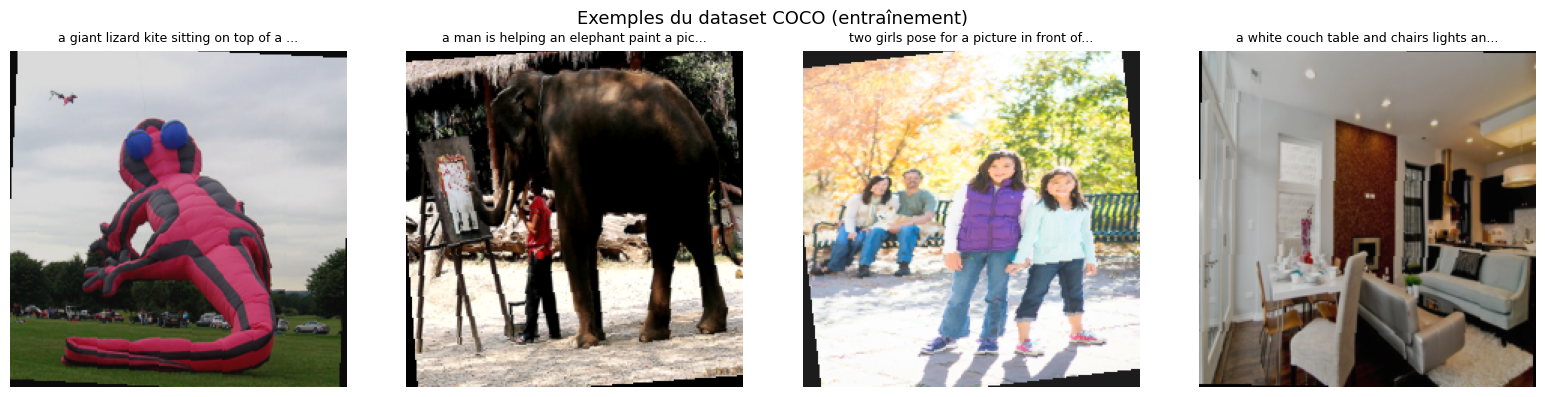

Shape des images : torch.Size([32, 3, 224, 224])
Shape des captions : torch.Size([32, 20])
Longueurs réelles : [14, 11, 13, 11, 14, 11, 13, 10]


In [34]:
sample_images, sample_captions, sample_lengths = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = sample_images[i].clone()
    img[0] = img[0] * 0.229 + 0.485
    img[1] = img[1] * 0.224 + 0.456
    img[2] = img[2] * 0.225 + 0.406
    img = img.clamp(0, 1)

    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(vocab.decode(sample_captions[i].tolist())[:40] + "...", fontsize=9)
    axes[i].axis('off')

plt.suptitle("Exemples du dataset COCO (entraînement)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Shape des images : {sample_images.shape}")
print(f"Shape des captions : {sample_captions.shape}")
print(f"Longueurs réelles : {sample_lengths[:8].tolist()}")


---

## Étape 3 — Encoder CNN (From Scratch)

6 blocs convolutionnels (VGG-like) avec 12 couches de convolution au total, BatchNorm, ReLU, MaxPool, puis projection vers un vecteur.


In [35]:
class CNNEncoder(nn.Module):
    """CNN Encoder from scratch. 6 blocs convolutionnels (12 couches conv) + pooling adaptatif + projection."""

    def __init__(self, embed_dim=512):
        super(CNNEncoder, self).__init__()

        # Bloc 1 : 3 → 32, image 224→112
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Bloc 2 : 32 → 64, image 112→56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Bloc 3 : 64 → 128, image 56→28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Bloc 4 : 128 → 256, image 28→14
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Bloc 5 : 256 → 512, image 14→7
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Bloc 6 : 512 → 512, image 7→3 (nouveau bloc pour plus de profondeur)
        self.block6 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, embed_dim)
        self.bn_fc = nn.BatchNorm1d(embed_dim)
        self.dropout = nn.Dropout(0.3)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, images):
        x = self.block1(images)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.bn_fc(x)
        return x


### Test rapide de l'encoder

In [37]:
test_encoder = CNNEncoder(embed_dim=config.HIDDEN_DIM)
dummy_input = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE)
output = test_encoder(dummy_input)
print(f"Input  : {dummy_input.shape}")
print(f"Output : {output.shape}")
print(f"→ Chaque image est résumée en un vecteur de dimension {output.shape[1]}")
del test_encoder, dummy_input, output

Input  : torch.Size([2, 3, 224, 224])
Output : torch.Size([2, 512])
→ Chaque image est résumée en un vecteur de dimension 512


---

## Étape 4 — Decoder LSTM

### Améliorations clés :
- **Pack padded sequences** : le LSTM ignore les tokens de padding (correction majeure vs Fixed)
- **2 couches LSTM** : plus de capacité pour un vocabulaire plus riche (Flickr30k)
- **Scheduled teacher forcing** : le forward supporte un `tf_ratio` variable

### Architecture :
```
Image features ──→ init (h0, c0) du LSTM
                          │
          <start> → Embedding → LSTM (2 couches) → Linear → P("a") ✓
              "a" → Embedding → LSTM (2 couches) → Linear → P("dog") ✓
              ...
```

In [39]:
class LSTMDecoder(nn.Module):
    """Décodeur LSTM avec pack_padded_sequence et scheduled teacher forcing."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.35):
        super(LSTMDecoder, self).__init__()

        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.image_to_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.image_to_cell = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
                n = param.size(0)
                param.data[n // 4:n // 2].fill_(1.0)  # forget gate bias = 1
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.constant_(self.fc_out.bias, 0)

    def init_hidden(self, image_features):
        h0 = self.image_to_hidden(image_features).unsqueeze(0)
        c0 = self.image_to_cell(image_features).unsqueeze(0)
        h0 = h0.expand(self.num_layers, -1, -1).contiguous()
        c0 = c0.expand(self.num_layers, -1, -1).contiguous()
        return h0, c0

    def forward(self, image_features, captions, lengths, tf_ratio=1.0):
        """
        Forward avec pack_padded_sequence et teacher forcing optionnel.

        Si tf_ratio=1.0 : teacher forcing complet (on donne les vrais mots).
        Si tf_ratio<1.0 : à chaque pas, avec proba (1-tf_ratio), on utilise
                          la prédiction du modèle plutôt que le vrai mot.
        """
        h, c = self.init_hidden(image_features)
        batch_size = captions.size(0)
        max_len = captions[:, :-1].size(1)  # longueur sans le dernier token

        # --- Teacher forcing complet : utiliser pack_padded_sequence ---
        if tf_ratio >= 1.0:
            embeddings = self.dropout(self.embedding(captions[:, :-1]))
            packed_seq = pack_padded_sequence(
                embeddings, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            packed_output, _ = self.lstm(packed_seq, (h, c))
            lstm_out, _ = pad_packed_sequence(packed_output, batch_first=True)
            outputs = self.fc_out(self.dropout(lstm_out))
            return outputs

        # --- Teacher forcing partiel : boucle pas à pas ---
        outputs = torch.zeros(batch_size, max_len, self.vocab_size, device=image_features.device)
        current_input = captions[:, 0].unsqueeze(1)  # <start>

        for t in range(max_len):
            embed = self.dropout(self.embedding(current_input))
            lstm_out, (h, c) = self.lstm(embed, (h, c))
            step_output = self.fc_out(self.dropout(lstm_out.squeeze(1)))
            outputs[:, t, :] = step_output

            # Décider si on utilise le vrai mot ou la prédiction
            if t + 1 < max_len:
                use_teacher = random.random() < tf_ratio
                if use_teacher:
                    current_input = captions[:, t + 1].unsqueeze(1)
                else:
                    current_input = step_output.argmax(dim=1).unsqueeze(1)

        return outputs

    def generate(self, image_features, vocab, max_len=30, beam_size=1):
        """Génération à l'inférence (greedy ou beam search)."""
        self.eval()
        with torch.no_grad():
            if beam_size <= 1:
                return self._greedy_decode(image_features, vocab, max_len)
            else:
                return self._beam_search(image_features, vocab, max_len, beam_size)

    def _greedy_decode(self, image_features, vocab, max_len):
        h, c = self.init_hidden(image_features)
        current_word = torch.tensor([[vocab.word2idx["<start>"]]], device=image_features.device)
        generated = []

        for _ in range(max_len):
            embed = self.embedding(current_word)
            lstm_out, (h, c) = self.lstm(embed, (h, c))
            scores = self.fc_out(lstm_out.squeeze(1))
            predicted_idx = scores.argmax(dim=1).item()

            if predicted_idx == vocab.word2idx["<end>"]:
                break
            generated.append(predicted_idx)
            current_word = torch.tensor([[predicted_idx]], device=image_features.device)

        return vocab.decode(generated)

    def _beam_search(self, image_features, vocab, max_len, beam_size):
        h, c = self.init_hidden(image_features)
        start_idx = vocab.word2idx["<start>"]
        end_idx = vocab.word2idx["<end>"]

        beams = [(0.0, [start_idx], h, c)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for score, seq, h_beam, c_beam in beams:
                last_word = torch.tensor([[seq[-1]]], device=image_features.device)
                embed = self.embedding(last_word)
                lstm_out, (h_new, c_new) = self.lstm(embed, (h_beam, c_beam))
                log_probs = F.log_softmax(self.fc_out(lstm_out.squeeze(1)), dim=1)

                top_scores, top_indices = log_probs.topk(beam_size, dim=1)
                for i in range(beam_size):
                    new_score = score + top_scores[0, i].item()
                    new_idx = top_indices[0, i].item()
                    new_seq = seq + [new_idx]
                    if new_idx == end_idx:
                        completed.append((new_score / len(new_seq), new_seq))
                    else:
                        new_beams.append((new_score, new_seq, h_new.clone(), c_new.clone()))

            if not new_beams:
                break
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_size]

        for score, seq, _, _ in beams:
            completed.append((score / len(seq), seq))

        if not completed:
            return ""
        completed.sort(key=lambda x: x[0], reverse=True)
        return vocab.decode(completed[0][1])

---

## Étape 5 — Modèle Complet (Encoder + Decoder)

In [40]:
class ImageCaptioningModel(nn.Module):
    """Modèle complet : CNN Encoder + LSTM Decoder."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.35):
        super(ImageCaptioningModel, self).__init__()
        self.encoder = CNNEncoder(embed_dim=hidden_dim)
        self.decoder = LSTMDecoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)

    def forward(self, images, captions, lengths, tf_ratio=1.0):
        features = self.encoder(images)
        outputs = self.decoder(features, captions, lengths, tf_ratio)
        return outputs

    def generate_caption(self, image, vocab, max_len=30, beam_size=3):
        self.eval()
        with torch.no_grad():
            features = self.encoder(image.unsqueeze(0))
            return self.decoder.generate(features, vocab, max_len, beam_size)


model = ImageCaptioningModel(
    vocab_size=len(vocab),
    embed_dim=config.EMBED_DIM,
    hidden_dim=config.HIDDEN_DIM,
    num_layers=config.NUM_LSTM_LAYERS,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux       : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")
print(f"Taille du vocabulaire   : {len(vocab)}")

Paramètres totaux       : 20,759,153
Paramètres entraînables : 20,759,153
Taille du vocabulaire   : 8913


---

## Étape 6 — Loss, Optimiseur et Scheduler

### Label Smoothing (nouveau)

Au lieu de targets one-hot durs (0 ou 1), on lisse les targets : le vrai mot reçoit une proba de 0.9 et le reste est réparti sur les autres mots. Cela empêche le modèle d'être trop confiant dans ses prédictions et améliore la généralisation.

In [41]:
# Cross-Entropy avec label smoothing
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=config.LABEL_SMOOTHING)

optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

scaler = GradScaler('cuda', enabled=config.USE_AMP)

print(f"Loss      : CrossEntropyLoss (ignore padding, label_smoothing={config.LABEL_SMOOTHING})")
print(f"Optimizer : Adam (lr={config.LEARNING_RATE})")
print(f"Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"AMP       : {config.USE_AMP}")

Loss      : CrossEntropyLoss (ignore padding, label_smoothing=0.1)
Optimizer : Adam (lr=0.0003)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)
AMP       : False


---

##  Étape 7 — Fonctions d'Entraînement et de Validation

### Teacher forcing décroissant

Le `tf_ratio` diminue linéairement au fil des epochs :
- Epoch 1 : `tf_ratio = 1.0` (100% vrais mots → apprentissage rapide)
- Epoch 50 : `tf_ratio = 0.6` (40% du temps, le modèle utilise ses propres prédictions)

Cela réduit l'**exposure bias** : le modèle apprend progressivement à gérer ses propres erreurs.

In [44]:
def get_tf_ratio(epoch, total_epochs, tf_start, tf_end):
    """Teacher forcing ratio décroissant linéairement."""
    return tf_start - (tf_start - tf_end) * epoch / max(total_epochs - 1, 1)


def train_one_epoch(model, dataloader, criterion, optimizer, scaler, config, tf_ratio=1.0):
    """Entraîne le modèle pour une epoch avec Mixed Precision et teacher forcing."""
    model.train()
    total_loss = 0
    num_batches = 0

    for batch_idx, (images, captions, lengths) in enumerate(dataloader):
        images = images.to(config.DEVICE, non_blocking=True)
        captions = captions.to(config.DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=config.USE_AMP):
            decoder_lengths = lengths - 1
            outputs = model(images, captions, decoder_lengths, tf_ratio=tf_ratio)
            targets = captions[:, 1:]

            # Aligner les dimensions (le target peut être plus long que l'output si tf < 1)
            min_len = min(outputs.size(1), targets.size(1))
            loss = criterion(
                outputs[:, :min_len, :].reshape(-1, outputs.size(-1)),
                targets[:, :min_len].reshape(-1)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        num_batches += 1

        if (batch_idx + 1) % 200 == 0:
            print(f"    Batch {batch_idx+1}/{len(dataloader)} - Loss: {loss.item():.4f}")

    return total_loss / max(num_batches, 1)


def evaluate(model, dataloader, criterion, config):
    """Évalue le modèle (toujours avec teacher forcing complet)."""
    model.eval()
    total_loss = 0
    num_batches = 0

    with torch.no_grad():
        for images, captions, lengths in dataloader:
            images = images.to(config.DEVICE, non_blocking=True)
            captions = captions.to(config.DEVICE, non_blocking=True)

            with autocast('cuda', enabled=config.USE_AMP):
                decoder_lengths = lengths - 1
                outputs = model(images, captions, decoder_lengths, tf_ratio=1.0)
                targets = captions[:, 1:]
                min_len = min(outputs.size(1), targets.size(1))
                loss = criterion(
                    outputs[:, :min_len, :].reshape(-1, outputs.size(-1)),
                    targets[:, :min_len].reshape(-1)
                )

            total_loss += loss.item()
            num_batches += 1

    return total_loss / max(num_batches, 1)

---

##  Étape 8 — Boucle d'Entraînement Principale

Avec **reprise d'entraînement** (checkpoint resume) et **teacher forcing décroissant**.

In [19]:
import os
for d in os.listdir("/kaggle/input/"):
    print(d)
    full = os.path.join("/kaggle/input/", d)
    if os.path.isdir(full):
        for f in os.listdir(full):
            print(f"  {f}")

datasets
  eliasmassaro
  awsaf49
  arnabd2002


In [20]:
import os
for root, dirs, files in os.walk("/kaggle/input/datasets/eliasmassaro/"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/eliasmassaro/coco-checkpoint-epoch9/best_model (2).pth


In [24]:
import shutil
src ="/kaggle/input/datasets/eliasmassaro/coco-checkpoint-epoch12/best_model (4).pth"
dst = os.path.join(config.SAVE_DIR, "best_model.pth")
os.makedirs(config.SAVE_DIR, exist_ok=True)
shutil.copy2(src, dst)
print(f"Checkpoint copié dans {dst}")

Checkpoint copié dans /kaggle/working/checkpoint_coco/best_model.pth


In [ ]:
os.makedirs(config.SAVE_DIR, exist_ok=True)

train_losses = []
val_losses = []

print("=" * 60)
print(f"Début de l'entraînement — {config.NUM_EPOCHS} epochs")
print(f"Device : {config.DEVICE} | AMP : {config.USE_AMP} | Batch : {config.BATCH_SIZE}")
print(f"Teacher Forcing : {config.TF_RATIO_START} → {config.TF_RATIO_END}")
print(f"Batches/epoch : {len(train_loader)}")
print("=" * 60)

# --- Système de reprise d'entraînement ---
checkpoint_path = os.path.join(config.SAVE_DIR, 'best_model.pth')
start_epoch = 0
best_val_loss = float('inf')

if os.path.exists(checkpoint_path):
    print(f" Checkpoint trouvé. Reprise de l'entraînement...")
    import torch.serialization

    torch.serialization.add_safe_globals([Vocabulary])
    checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['val_loss']
    print(f"Reprise à l'epoch {start_epoch} (best val_loss = {best_val_loss:.4f})")
else:
    print("Aucun checkpoint trouvé. Entraînement from scratch.")

print("=" * 60)

for epoch in range(start_epoch, config.NUM_EPOCHS):
    start_time = time.time()

    # Teacher forcing décroissant
    tf_ratio = get_tf_ratio(
        epoch, config.NUM_EPOCHS, config.TF_RATIO_START, config.TF_RATIO_END
    )

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, config, tf_ratio=tf_ratio
    )
    val_loss = evaluate(model, val_loader, criterion, config)
    scheduler.step(val_loss)

    elapsed = time.time() - start_time
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:2d}/{config.NUM_EPOCHS} ({elapsed:.0f}s) | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
          f"TF: {tf_ratio:.2f}", end="")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_loss,
            'vocab': vocab,
        }, checkpoint_path)
        print(f" ★ BEST", end="")

    print()

    if (epoch + 1) % 5 == 0:
        model.eval()
        sample_img, sample_cap, _ = next(iter(val_loader))
        sample_img = sample_img[:1].to(config.DEVICE)
        with torch.no_grad():
            features = model.encoder(sample_img)
            generated = model.decoder.generate(features, vocab, max_len=25, beam_size=3)
        ref = vocab.decode(sample_cap[0].tolist())
        print(f"  Réf : {ref}")
        print(f"  Gén : {generated}")

print(f"\nTerminé ! Meilleure val_loss = {best_val_loss:.4f}")

Début de l'entraînement — 30 epochs
Device : cuda | AMP : False | Batch : 32
Teacher Forcing : 1.0 → 0.6
Batches/epoch : 7393
✅ Checkpoint trouvé. Reprise de l'entraînement...


/tmp/ipykernel_55/120941410.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE)


Reprise à l'epoch 19 (best val_loss = 3.4133)
    Batch 200/7393 - Loss: 3.5815
    Batch 400/7393 - Loss: 3.9541
    Batch 600/7393 - Loss: 3.5789
    Batch 800/7393 - Loss: 3.6471
    Batch 1000/7393 - Loss: 3.7899
    Batch 1200/7393 - Loss: 3.8812
    Batch 1400/7393 - Loss: 3.7682
    Batch 1600/7393 - Loss: 3.2367
    Batch 1800/7393 - Loss: 3.7529
    Batch 2000/7393 - Loss: 3.4595
    Batch 2200/7393 - Loss: 4.0169
    Batch 2400/7393 - Loss: 3.8149
    Batch 2600/7393 - Loss: 3.3845
    Batch 2800/7393 - Loss: 4.0282
    Batch 3000/7393 - Loss: 3.7812
    Batch 3200/7393 - Loss: 3.5289
    Batch 3400/7393 - Loss: 3.8772
    Batch 3600/7393 - Loss: 4.1402
    Batch 3800/7393 - Loss: 3.7170
    Batch 4000/7393 - Loss: 3.5215
    Batch 4200/7393 - Loss: 3.5337
    Batch 4400/7393 - Loss: 3.7920
    Batch 4600/7393 - Loss: 3.6208
    Batch 4800/7393 - Loss: 4.0832
    Batch 5000/7393 - Loss: 3.5774
    Batch 5200/7393 - Loss: 3.5340
    Batch 5400/7393 - Loss: 3.6410
    Batch 560

---

##  Étape 9 — Visualisation des Courbes de Loss

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss', markersize=4)
plt.plot(range(1, len(val_losses)+1), val_losses, 'r-o', label='Validation Loss', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title("Courbes d'entraînement")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

##  Étape 10 — Évaluation BLEU Multi-Références

### Amélioration : BLEU avec les 5 références

Chaque image de Flickr30k a 5 captions de référence. Le BLEU standard ne compare qu'à une seule référence (celle du batch). Ici, on charge les 5 références et on prend le **meilleur score** parmi les 5 — c'est plus juste et plus représentatif.

In [ ]:
def compute_bleu(reference, hypothesis, max_n=4):
    """Calcul du score BLEU-n."""
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()

    if len(hyp_tokens) == 0:
        return 0.0

    bp = min(1.0, math.exp(1 - len(ref_tokens) / max(len(hyp_tokens), 1)))

    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter()
        hyp_ngrams = Counter()

        for i in range(len(ref_tokens) - n + 1):
            ref_ngrams[tuple(ref_tokens[i:i+n])] += 1
        for i in range(len(hyp_tokens) - n + 1):
            hyp_ngrams[tuple(hyp_tokens[i:i+n])] += 1

        clipped = sum(min(hyp_ngrams[ng], ref_ngrams[ng]) for ng in hyp_ngrams)
        total = max(sum(hyp_ngrams.values()), 1)
        precisions.append(clipped / total)

    if any(p == 0 for p in precisions):
        return 0.0

    log_avg = sum(math.log(p) for p in precisions) / max_n
    return bp * math.exp(log_avg)


def load_all_references_coco(annot_file, images_dir):
    """Charge toutes les références COCO (toutes les captions par image) pour l'évaluation multi-ref."""
    import json as json_lib
    with open(annot_file, 'r') as f:
        data = json_lib.load(f)

    id_to_file = {img['id']: img['file_name'] for img in data['images']}

    refs = defaultdict(list)
    for ann in data['annotations']:
        filename = id_to_file[ann['image_id']]
        refs[filename].append(ann['caption'].strip().lower())

    return refs


def compute_bleu_multi_ref(references_list, hypothesis, max_n=4):
    """BLEU avec multi-références : prend le meilleur score parmi les N références."""
    return max(compute_bleu(ref, hypothesis, max_n) for ref in references_list)


In [ ]:
import torch.serialization
torch.serialization.add_safe_globals([Vocabulary])

# Charger le meilleur modèle
checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Meilleur modèle chargé (epoch {checkpoint['epoch']+1}, val_loss={checkpoint['val_loss']:.4f})")

# Charger toutes les références pour le test (on utilise TOUTES les captions pour l'évaluation)
all_refs = load_all_references_coco(config.VAL_ANNOT, config.VAL_IMAGES_DIR)
# Filtrer pour ne garder que les images du test set
test_refs = {k: v for k, v in all_refs.items() if k in test_image_set}
print(f"Images dans le test set avec références : {len(test_refs)}")

# Dataset de test
print("\nChargement du dataset de test :")
test_dataset = COCODataset(
    config.VAL_IMAGES_DIR, test_pairs,
    vocab, get_transforms(config.IMG_SIZE, is_train=False), config.MAX_CAPTION_LEN
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, collate_fn=COCODataset.collate_fn
)


In [ ]:
# Évaluation BLEU multi-références sur 200 images
bleu_scores_single = []
bleu_scores_multi = []
examples = []
model.eval()

# On veut évaluer par image (pas par caption), donc on track les images déjà vues
seen_images = set()
eval_count = 0

for i, (images, captions, lengths) in enumerate(test_loader):
    if eval_count >= 200:
        break

    images = images.to(config.DEVICE)
    with torch.no_grad():
        features = model.encoder(images)
        generated = model.decoder.generate(features, vocab, max_len=25, beam_size=3)

    # Référence simple (celle du batch)
    reference = vocab.decode(captions[0].tolist())
    bleu_single = compute_bleu(reference, generated, max_n=4)
    bleu_scores_single.append(bleu_single)

    # Référence multiple (si disponible)
    img_name = test_dataset.image_captions[i][0]
    if img_name in test_refs and img_name not in seen_images:
        bleu_multi = compute_bleu_multi_ref(test_refs[img_name], generated, max_n=4)
        bleu_scores_multi.append(bleu_multi)
        seen_images.add(img_name)
        eval_count += 1

        if len(examples) < 10:
            examples.append((images[0].cpu(), reference, generated, bleu_multi))

print(f"\n--- BLEU-4 (single reference, {len(bleu_scores_single)} captions) ---")
print(f"  Moyen  : {np.mean(bleu_scores_single):.4f}")
print(f"  Médian : {np.median(bleu_scores_single):.4f}")

print(f"\n--- BLEU-4 (multi-reference, {len(bleu_scores_multi)} images) ---")
print(f"  Moyen  : {np.mean(bleu_scores_multi):.4f}")
print(f"  Médian : {np.median(bleu_scores_multi):.4f}")
print(f"  Max    : {np.max(bleu_scores_multi):.4f}")


---

##  Étape 11 — Exemples Visuels de Résultats

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))

for i, (img_tensor, ref, gen, bleu) in enumerate(examples[:10]):
    ax = axes[i // 5][i % 5]

    img = img_tensor.clone()
    img[0] = img[0] * 0.229 + 0.485
    img[1] = img[1] * 0.224 + 0.456
    img[2] = img[2] * 0.225 + 0.406
    img = img.clamp(0, 1)

    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"BLEU-4: {bleu:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel(f"Réf: {ref[:50]}...\nGén: {gen[:50]}...", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Résultats sur le Test Set (BLEU multi-ref)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

##  Étape 12 — Démo : Légender une Nouvelle Image

In [ ]:
def caption_new_image(image_path, model, vocab, config):
    """Génère et affiche une caption pour une image quelconque."""
    transform = get_transforms(config.IMG_SIZE, is_train=False)

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).to(config.DEVICE)

    model.eval()
    with torch.no_grad():
        features = model.encoder(image_tensor.unsqueeze(0))
        greedy_caption = model.decoder.generate(features, vocab, max_len=25, beam_size=1)
        beam_caption = model.decoder.generate(features, vocab, max_len=25, beam_size=3)
        beam5_caption = model.decoder.generate(features, vocab, max_len=25, beam_size=5)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Greedy   : "{greedy_caption}"\n'
              f'Beam(k=3): "{beam_caption}"\n'
              f'Beam(k=5): "{beam5_caption}"',
              fontsize=11, pad=20)
    plt.tight_layout()
    plt.show()

    return greedy_caption, beam_caption, beam5_caption


# ===== CHANGER LE CHEMIN ICI POUR L'EXAMEN =====
# caption_new_image("chemin/vers/image_test.jpg", model, vocab, config)

---

##  Sauvegarde du modèle

Sur Kaggle, les fichiers sauvés dans `/kaggle/working/` sont disponibles dans l'onglet **Output** du notebook après exécution.
Vous pouvez les télécharger depuis là.

In [ ]:
# Sur Kaggle, les fichiers dans /kaggle/working/ sont accessibles dans Output
save_path = "/kaggle/working/checkpoint_coco/"
os.makedirs(save_path, exist_ok=True)

final_save = os.path.join(save_path, "best_model_optimized.pth")
checkpoint_src = os.path.join(config.SAVE_DIR, "best_model.pth")

if os.path.exists(checkpoint_src):
    shutil.copy2(checkpoint_src, final_save)
    print(f"✅ Modèle sauvegardé : {final_save}")
    print("Téléchargez-le depuis l'onglet Output du notebook Kaggle")
else:
    print("⚠️ Aucun checkpoint trouvé à sauvegarder")


---

##  Résumé du Projet — Version Optimisée

| Composant | Choix | Justification |
|-----------|-------|---------------|
| **Dataset** | MS COCO 2017 (~118k images train) | Dataset de référence, grande diversité de scènes |
| **Captions/image** | 2 (sur 5 disponibles) | Limite la charge mémoire et le temps d'entraînement |
| **Images** | 224×224 | Features plus détaillées pour le CNN |
| **Encoder** | CNN 6 blocs / 12 couches (VGG-like) | Hiérarchie de features plus profonde, from scratch |
| **Decoder** | LSTM **2 couches** | Plus de capacité pour le vocabulaire COCO |
| **Pack padded seq** |  Activé | Le LSTM ignore correctement le padding |
| **Teacher forcing** | Scheduled (1.0 → 0.6) | Réduit l'exposure bias progressivement |
| **Loss** | CrossEntropy + **label smoothing 0.1** | Régularise, empêche l'over-confidence |
| **Data augmentation** | Crop + Flip + Rotation + ColorJitter | Régularisation maximale |
| **Optimiseur** | Adam (lr=3e-4) | Convergence rapide, adaptatif |
| **Scheduler** | ReduceLROnPlateau | Affine le lr quand val_loss stagne |
| **Checkpoint** | Resume training | Reprend l'entraînement si interruption |
| **Inférence** | Beam Search (k=3 et k=5) | Explore plus de chemins |
| **Métrique** | BLEU-4 **multi-références** | Utilise les captions de référence de chaque image |
| **GPU** | Kaggle GPU (T4/P100) + AMP + cuDNN benchmark | ~2x speedup |
